<a href="https://colab.research.google.com/github/naamasarshalom-art/segmentation_cellpose/blob/main/7_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full Pipeline — Nucleus Morphology Analysis by Genotype

This notebook runs the complete analysis pipeline from raw microscopy images
to per-genotype morphology percentages.

**Input folder structure:**
```
INPUT_DIR/
    genotype_A/
        image1.tif
        image2.nd2
    genotype_B/
        ...
```

**Pipeline per image:**
1. Segmentation (Cellpose) — crop individual nuclei from raw microscopy image
2. Model 1 (RADIO + SVM) — filter trash/artifacts vs classifiable nuclei
3. Model 2 (DINOv3 + Logistic Regression) — classify good / unclass / invaginated
4. Aggregate results per genotype and export to Excel + bar chart

**Classification thresholds for Model 2:**
- prob(invaginated) < 0.3  -> `good`
- prob(invaginated) > 0.8  -> `invaginated`
- otherwise                -> `unclass`

**Output:**
- Cropped nucleus images + overview images (per genotype subfolder)
- `genotype_summary.xlsx` with counts and percentages
- Bar chart of invaginated percentage per genotype

## 1. Setup — Mount Drive & Install Dependencies

In [1]:

from google.colab import drive
drive.mount('/content/drive')

!pip install git+https://www.github.com/mouseland/cellpose.git
!pip install nd2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-eiszlh_0
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-eiszlh_0
  Resolved https://www.github.com/mouseland/cellpose.git to commit c69c4ae75d7d08a3677039be3334327f04cc4f5d
  Preparing metadata (setup.py) ... done


## 2. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import joblib
import tifffile as tiff
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import nd2

import torch
from pathlib import Path
from natsort import natsorted
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
from tqdm.auto import tqdm
from scipy import ndimage as ndi

from cellpose import models as cp_models, core, io
from transformers import AutoModel, AutoImageProcessor

## 3. Configuration

**This is the only cell that needs to be changed between experiments.**

In [9]:
# ── Input ──────────────────────────────────────────────────────────────────
# Root folder containing one subfolder per genotype.
# Each subfolder contains raw microscopy images (.tif / .nd2).
INPUT_DIR = "/content/drive/MyDrive/model_nuc/batch 1 - 20.10.25/"  # <- change per experiment

# ── Output ─────────────────────────────────────────────────────────────────
# Cropped nuclei and overview images will be saved here (mirroring input structure)
OUTPUT_DIR   = "/content/drive/MyDrive/model_nuc/results"
OUTPUT_EXCEL = "/content/drive/MyDrive/model_nuc/results/genotype_summary_1.xlsx"

# ── Trained model files ────────────────────────────────────────────────────
# Model 1: StandardScaler + SVM (no PCA — best config was no_PCA)
MODEL1_SCALER = "/content/drive/MyDrive/model_nuc/model1_scaler.pkl"
MODEL1_SVM    = "/content/drive/MyDrive/model_nuc/model1_svm.pkl"

# Model 2: StandardScaler + PCA (if used) + classifier
MODEL2_SCALER = "/content/drive/MyDrive/model_nuc/model2_scaler.pkl"
MODEL2_PCA    = "/content/drive/MyDrive/model_nuc/model2_pca.pkl"
MODEL2_CLF    = "/content/drive/MyDrive/model_nuc/model2_clf.pkl"

# DINOv2 weights (local path on Drive)
DINO_WEIGHTS  = "/content/drive/MyDrive/model_nuc/model_dinov3/dinov3_b16_weights"

# ── Segmentation (Cellpose) ────────────────────────────────────────────────
ALPHA              = 0.3   # weight for channel 0 (blue) in weighted input
BETA               = 0.7   # weight for channel 1 (red)
PADDING            = 20    # pixels around each nucleus bounding box
FLOW_THRESHOLD     = 0.2
CELLPROB_THRESHOLD = 0.0

# ── Model 2 classification thresholds ─────────────────────────────────────
# prob(invaginated) < THRESH_GOOD        -> good
# prob(invaginated) > THRESH_INVAGINATED -> invaginated
# otherwise                              -> unclass
THRESH_GOOD        = 0.3
THRESH_INVAGINATED = 0.8

# ── Supported input formats ────────────────────────────────────────────────
SUPPORTED_EXTENSIONS = [".tif", ".tiff", ".nd2"]



## 4. Load All Models

Requires GPU. Go to Runtime -> Change runtime type -> GPU if this cell fails.

In [4]:
device = "cuda"

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Go to Runtime -> Change runtime type -> GPU.")

# ── Cellpose ───────────────────────────────────────────────────────────────
io.logger_setup()
cellpose_model = cp_models.CellposeModel(gpu=True)
print("Cellpose loaded")

# ── RADIO (Model 1 feature extractor) ─────────────────────────────────────
radio_model = torch.hub.load(
    'NVlabs/RADIO', 'radio_model',
    version='c-radio_v4-h',
    skip_validation=True, force_reload=False
)
radio_model.to(device).eval()
print("RADIO loaded")

# ── DINOv2 (Model 2 feature extractor) ────────────────────────────────────
try:
    dino_model     = AutoModel.from_pretrained(DINO_WEIGHTS).to(device).eval()
    dino_processor = AutoImageProcessor.from_pretrained(DINO_WEIGHTS)
except Exception as e:
    print(f"Retrying with trust_remote_code=True ({e})")
    dino_model     = AutoModel.from_pretrained(DINO_WEIGHTS, trust_remote_code=True).to(device).eval()
    dino_processor = AutoImageProcessor.from_pretrained(DINO_WEIGHTS, trust_remote_code=True)
print("DINOv2 loaded")

# ── Model 1 classifiers: scaler + SVM (no PCA) ────────────────────────────
scaler_m1 = joblib.load(MODEL1_SCALER)
clf_m1    = joblib.load(MODEL1_SVM)

# ── Model 2 classifier: scaler + PCA (if used) + clf ─────────────────────
scaler_m2 = joblib.load(MODEL2_SCALER)
pca_m2    = joblib.load(MODEL2_PCA) if MODEL2_PCA else None
clf_m2    = joblib.load(MODEL2_CLF)

print("Classifiers loaded")
print("\nAll models ready.")

[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.1.2.dev67+gc69c4ae75 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-17 07:50:42,741 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-17 07:50:42,743 [io INFO] 
cellpose version: 	4.1.2.dev67+gc69c4ae75 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-17 07:50:43,016 [core INFO] ** TORCH CUDA version installed and working. **
2026-05-17 07:50:43,018 [core INFO] >>>> using GPU (CUDA)
2026-05-17 07:50:45,531 [models INFO] >>>> loading model /root/.cellpose/models/cpsam
Cellpose loaded


Using cache found in /root/.cache/torch/hub/NVlabs_RADIO_main
/root/.cache/torch/hub/NVlabs_RADIO_main/hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


RADIO loaded


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINOv2 loaded
Classifiers loaded

All models ready.


## 5. Helper Functions

In [5]:
# ── Image I/O ──────────────────────────────────────────────────────────────

def read_image(file_path):
    """
    Read a .tif/.tiff or .nd2 microscopy image.
    Returns numpy array in (H, W, C) layout.
    """
    ext = Path(file_path).suffix.lower()
    if ext in [".tif", ".tiff"]:
        with tiff.TiffFile(file_path) as f:
            img = f.asarray()
    elif ext == ".nd2":
        with nd2.ND2File(file_path) as f:
            img = f.asarray()
    else:
        raise ValueError(f"Unsupported format: {ext}")
    return np.moveaxis(img, 0, -1)   # (C, H, W) -> (H, W, C)


def normalize_to_uint8(x):
    """Normalize array to [0, 255] uint8."""
    return ((x - x.min()) / (x.max() - x.min() + 1e-8) * 255).astype(np.uint8)


def build_weighted_input(img_hwc):
    """Build single-channel weighted blend for Cellpose: alpha*ch0 + beta*ch1."""
    weighted = ALPHA * img_hwc[:, :, 0] + BETA * img_hwc[:, :, 1]
    return weighted[..., np.newaxis]   # (H, W, 1)


def build_rgb_display(img_hwc):
    """Build uint8 RGB for saving: red <- ch1, blue <- ch0."""
    H, W = img_hwc.shape[:2]
    rgb = np.zeros((H, W, 3), dtype=np.uint8)
    rgb[:, :, 0] = normalize_to_uint8(img_hwc[:, :, 1])
    rgb[:, :, 2] = normalize_to_uint8(img_hwc[:, :, 0])
    return rgb


# ── Segmentation ───────────────────────────────────────────────────────────

def segment_and_crop(file_path, output_dir):
    """
    Run Cellpose segmentation on a single image file.
    Saves individual nucleus crops as JPG and one overview image.

    Returns:
        list of str: paths to the saved nucleus crop files.
    """
    img_hwc   = read_image(file_path)
    H, W      = img_hwc.shape[:2]
    stem      = Path(file_path).stem

    # Run Cellpose on weighted channel blend
    img_weighted = build_weighted_input(img_hwc)
    masks, _, _  = cellpose_model.eval(
        img_weighted,
        batch_size=32,
        flow_threshold=FLOW_THRESHOLD,
        cellprob_threshold=CELLPROB_THRESHOLD,
        normalize={"tile_norm_blocksize": 0}
    )

    # Find connected components
    labeled_cc, num_cc = ndi.label(masks > 0)

    crop_paths  = []
    bbox_list   = []

    for cc_label in range(1, num_cc + 1):
        ys, xs = np.where(labeled_cc == cc_label)
        if len(xs) == 0:
            continue

        x1 = max(0, xs.min() - PADDING)
        y1 = max(0, ys.min() - PADDING)
        x2 = min(W - 1, xs.max() + PADDING)
        y2 = min(H - 1, ys.max() + PADDING)

        crop_rgb  = build_rgb_display(img_hwc[y1:y2+1, x1:x2+1, :])
        crop_name = f"{stem}.{x1}_{y1}_{x2}_{y2}.jpg"
        crop_path = str(Path(output_dir) / crop_name)
        imageio.imwrite(crop_path, crop_rgb)

        crop_paths.append(crop_path)
        bbox_list.append((x1, y1, x2, y2))

    # Save overview image with bounding boxes
    full_rgb = build_rgb_display(img_hwc)
    fig, ax  = plt.subplots(figsize=(8, 8))
    ax.imshow(full_rgb)
    ax.set_title(f"{Path(file_path).name} — {num_cc} nuclei")
    for x1, y1, x2, y2 in bbox_list:
        ax.add_patch(plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            edgecolor='yellow', facecolor='none', linewidth=1.5
        ))
    ax.axis('off')
    overview_path = str(Path(output_dir) / f"{stem}_overview.jpg")
    fig.savefig(overview_path, bbox_inches='tight', dpi=150)
    plt.close(fig)

    return crop_paths


# ── Embedding extraction ───────────────────────────────────────────────────

@torch.no_grad()
def get_radio_embeddings(image_paths, batch_size=8):
    """
    Extract RADIO summary embeddings (2560-dim) for a list of image paths.
    """
    all_embs = []
    for i in range(0, len(image_paths), batch_size):
        batch   = image_paths[i:i+batch_size]
        pil_imgs = [Image.open(p).convert("RGB") for p in batch]
        w, h     = pil_imgs[0].size
        target   = radio_model.get_nearest_supported_resolution(h, w)
        tensors  = [
            pil_to_tensor(img.resize((target[1], target[0]), Image.BILINEAR)).float() / 255.0
            for img in pil_imgs
        ]
        x = torch.stack(tensors).to(device)
        summary, _ = radio_model(x)
        all_embs.append(summary.cpu().numpy())
    return np.vstack(all_embs)


@torch.no_grad()
def get_dino_embeddings(image_paths, batch_size=16):
    """
    Extract DINOv2 CLS token embeddings (768-dim) for a list of image paths.
    """
    all_embs = []
    for i in range(0, len(image_paths), batch_size):
        batch   = image_paths[i:i+batch_size]
        images  = [Image.open(p).convert("RGB") for p in batch]
        inputs  = dino_processor(images=images, return_tensors="pt").to(device)
        outputs = dino_model(**inputs)
        cls     = outputs.last_hidden_state[:, 0, :]
        all_embs.append(cls.cpu().numpy())
    return np.vstack(all_embs)


print("Helper functions ready.")

Helper functions ready.


## 6. Run Full Pipeline

For each genotype folder:
1. Segment all raw images -> save nucleus crops
2. Run Model 1 (RADIO) on all crops -> filter trash
3. Run Model 2 (DINOv2) on classifiable crops -> good / unclass / invaginated
4. Compute percentages

In [10]:
# Collect genotype folders
genotype_dirs = natsorted([
    d for d in Path(INPUT_DIR).iterdir()
    if d.is_dir()
])

if not genotype_dirs:
    raise FileNotFoundError(f"No subfolders found in {INPUT_DIR}")

print(f"Found {len(genotype_dirs)} genotype folder(s):")
for d in genotype_dirs:
    print(f"  {d.name}")

results = []

for geno_dir in genotype_dirs:
    genotype = geno_dir.name

    # Output subfolder for this genotype's crops
    geno_output = Path(OUTPUT_DIR) / genotype
    geno_output.mkdir(parents=True, exist_ok=True)

    # Collect raw microscopy files
    raw_files = natsorted([
        f for f in geno_dir.iterdir()
        if f.suffix.lower() in SUPPORTED_EXTENSIONS
    ])

    if not raw_files:
        print(f"\n[{genotype}] No supported images found, skipping.")
        continue

    print(f"\n{'='*55}")
    print(f"Genotype: {genotype} — {len(raw_files)} image(s)")
    print(f"{'='*55}")

    # ── Step 1: Segmentation ──────────────────────────────────────────────
    print("  Step 1: Segmentation...")
    all_crop_paths = []
    for raw_file in tqdm(raw_files, desc=f"  Segmenting {genotype}"):
        overview = geno_output / f"{raw_file.stem}_overview.jpg"
        if overview.exists():
            existing = [str(p) for p in geno_output.glob(f"{raw_file.stem}.*.jpg")]
            all_crop_paths.extend(existing)
        else:
            crops = segment_and_crop(str(raw_file), str(geno_output))
            all_crop_paths.extend(crops)

    print(f"  Total nucleus crops: {len(all_crop_paths)}")

    if len(all_crop_paths) == 0:
        print(f"  No nuclei detected, skipping.")
        continue

    # ── Step 2: Model 1 — RADIO -> trash / classifiable ───────────────────
    print("  Step 2: Model 1 (RADIO)...")
    X_radio  = get_radio_embeddings(all_crop_paths, batch_size=8)
    X_scaled = scaler_m1.transform(X_radio)
    m1_preds = clf_m1.predict(X_scaled)   # no PCA for Model 1

    n_total        = len(all_crop_paths)
    n_trash        = (m1_preds == 1).sum()
    n_classifiable = (m1_preds == 0).sum()

    print(f"  Model 1 -> classifiable: {n_classifiable} | trash: {n_trash}")

    if n_classifiable == 0:
        print(f"  No classifiable nuclei, skipping Model 2.")
        continue

    # ── Step 3: Model 2 — DINOv2 -> good / unclass / invaginated ─────────
    print("  Step 3: Model 2 (DINOv2)...")
    classifiable_idx   = np.where(m1_preds == 0)[0]
    classifiable_paths = [all_crop_paths[i] for i in classifiable_idx]

    X_dino = get_dino_embeddings(classifiable_paths, batch_size=16)

    # Apply scaler
    X_dino_scaled = scaler_m2.transform(X_dino)

    # Apply PCA if used in best config
    if pca_m2 is not None:
        X_dino_scaled = pca_m2.transform(X_dino_scaled)

    m2_proba = clf_m2.predict_proba(X_dino_scaled)[:, 1]  # prob(invaginated)

    # Apply double threshold
    m2_labels = np.where(
        m2_proba < THRESH_GOOD, "good",
        np.where(m2_proba > THRESH_INVAGINATED, "invaginated", "unclass")
    )

    n_good        = (m2_labels == "good").sum()
    n_unclass     = (m2_labels == "unclass").sum()
    n_invaginated = (m2_labels == "invaginated").sum()

    # ── Step 4: Compute percentages ───────────────────────────────────────
    pct_trash       = 100 * n_trash        / n_total
    pct_good        = 100 * n_good          / n_classifiable
    pct_unclass     = 100 * n_unclass       / n_classifiable
    pct_invaginated = 100 * n_invaginated   / n_classifiable

    print(f"  Model 2 -> good: {n_good} | unclass: {n_unclass} | invaginated: {n_invaginated}")
    print(f"  % invaginated of classifiable: {pct_invaginated:.1f}%")
    print(f"  % good of classifiable:        {pct_good:.1f}%")
    print(f"  % unclass of classifiable:     {pct_unclass:.1f}%")
    print(f"  % trash of total:              {pct_trash:.1f}%")

    results.append({
        "genotype":                        genotype,
        "total_nuclei":                    n_total,
        "n_trash":                         n_trash,
        "n_classifiable":                  n_classifiable,
        "n_good":                          n_good,
        "n_unclass":                       n_unclass,
        "n_invaginated":                   n_invaginated,
        "pct_trash":                       round(pct_trash, 2),
        "pct_good_of_classifiable":        round(pct_good, 2),
        "pct_unclass_of_classifiable":     round(pct_unclass, 2),
        "pct_invaginated_of_classifiable": round(pct_invaginated, 2),
    })

print("\nPipeline complete.")

Found 1 genotype folder(s):
  123-test

Genotype: 123-test — 10 image(s)
  Step 1: Segmentation...


  Segmenting 123-test:   0%|          | 0/10 [00:00<?, ?it/s]

  Total nucleus crops: 27
  Step 2: Model 1 (RADIO)...
  Model 1 -> classifiable: 23 | trash: 4
  Step 3: Model 2 (DINOv2)...
  Model 2 -> good: 6 | unclass: 4 | invaginated: 13
  % invaginated of classifiable: 56.5%
  % good of classifiable:        26.1%
  % unclass of classifiable:     17.4%
  % trash of total:              14.8%

Pipeline complete.


## 7. Summary Table & Export to Excel

In [11]:
df_results = pd.DataFrame(results)

print("\n" + "="*70)
print("SUMMARY — Nucleus Morphology by Genotype")
print("="*70)
print(df_results[[
    "genotype", "total_nuclei",
    "n_trash", "n_classifiable",
    "n_good", "n_unclass", "n_invaginated",
    "pct_trash",
    "pct_good_of_classifiable",
    "pct_unclass_of_classifiable",
    "pct_invaginated_of_classifiable"
]].to_string(index=False))

# Save to Excel with auto-fit columns
Path(OUTPUT_EXCEL).parent.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    df_results.to_excel(writer, index=False, sheet_name="Results")
    ws = writer.sheets["Results"]
    for col in ws.columns:
        max_len = max((len(str(c.value)) for c in col if c.value), default=0)
        ws.column_dimensions[col[0].column_letter].width = max_len + 4

print(f"\nExcel saved: {OUTPUT_EXCEL}")


SUMMARY — Nucleus Morphology by Genotype
genotype  total_nuclei  n_trash  n_classifiable  n_good  n_unclass  n_invaginated  pct_trash  pct_good_of_classifiable  pct_unclass_of_classifiable  pct_invaginated_of_classifiable
123-test            27        4              23       6          4             13      14.81                     26.09                        17.39                            56.52

Excel saved: /content/drive/MyDrive/model_nuc/results/genotype_summary_1.xlsx


## 8. Bar Chart — Invaginated Percentage per Genotype

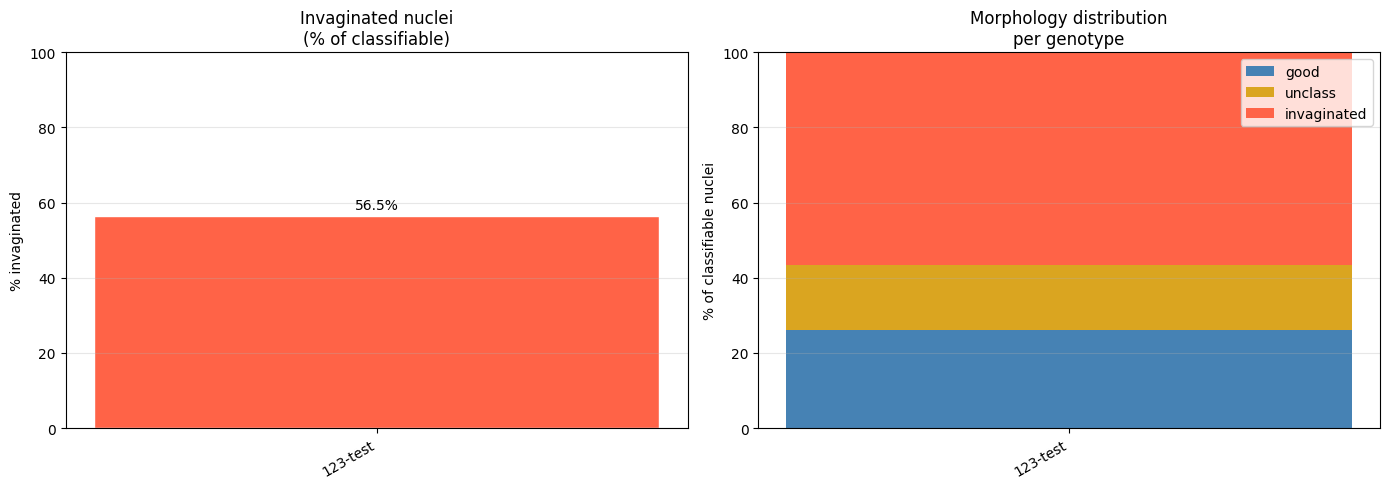

Chart saved: /content/drive/MyDrive/model_nuc/results/morphology_chart.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genotypes = df_results["genotype"].tolist()
x = np.arange(len(genotypes))

# ── Left: % invaginated of classifiable ───────────────────────────────────
bars1 = axes[0].bar(
    x,
    df_results["pct_invaginated_of_classifiable"],
    color="tomato", edgecolor="white", width=0.6
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(genotypes, rotation=30, ha="right")
axes[0].set_ylabel("% invaginated")
axes[0].set_title("Invaginated nuclei\n(% of classifiable)")
axes[0].set_ylim(0, 100)
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, df_results["pct_invaginated_of_classifiable"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

# ── Right: stacked bar — good / unclass / invaginated ─────────────────────
axes[1].bar(x, df_results["pct_good_of_classifiable"],
            label="good", color="steelblue", width=0.6)
axes[1].bar(x, df_results["pct_unclass_of_classifiable"],
            bottom=df_results["pct_good_of_classifiable"],
            label="unclass", color="goldenrod", width=0.6)
axes[1].bar(x, df_results["pct_invaginated_of_classifiable"],
            bottom=df_results["pct_good_of_classifiable"] + df_results["pct_unclass_of_classifiable"],
            label="invaginated", color="tomato", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(genotypes, rotation=30, ha="right")
axes[1].set_ylabel("% of classifiable nuclei")
axes[1].set_title("Morphology distribution\nper genotype")
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()

chart_path = str(Path(OUTPUT_EXCEL).parent / "morphology_chart.png")
fig.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")